### This file test the RePercENT model on synthetic data

In [82]:
import sys
import os

sys.path.append(os.getcwd())
# append the root directory to the sys.path

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Define imports here

In [83]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from src.utils.synthetic_dataset import GenerateData, MultimodalDataset
from src.utils.helpers import linear_probe, extract_latents_and_labels, plot_confusion_matrix, non_linear_probe
from training.main import make_model
from src.models.repercent import RePercENT
import math
from tqdm.notebook import tqdm
from torch.utils.data import random_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
import numpy as np
import yaml

In [84]:
base_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))

# device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


### Read config files

In [85]:
# Read the configuration files for data
data_config_path = os.path.join(base_dir, "configs", "data", "synthetic_data.yaml")
with open(data_config_path, 'r') as f:
    data_config = yaml.safe_load(f)
# Read the configuration files for the model
model_config_path = os.path.join(base_dir, "configs", "model", "repercent.yaml")
with open(model_config_path, 'r') as f:
    model_config = yaml.safe_load(f)
# Read the configuration files for training
training_config_path = os.path.join(base_dir, "configs", "training", "train_synthetic.yaml")
with open(training_config_path, 'r') as f:
    training_config = yaml.safe_load(f)

### Load dataset and train/test split

In [86]:
dataset_dir = os.path.join(base_dir, 'data', 'repercent_synthetic', 'dataset5')

# Load the train and test datasets
data_split = torch.load(os.path.join(dataset_dir, 'data_split.pt'), weights_only=False)
train_dataset = data_split['train_dataset']
test_dataset = data_split['test_dataset']

train_dataloader = DataLoader(train_dataset, batch_size= training_config['training']['batch_size'], shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=training_config['training']['batch_size'], shuffle=False)

### Initialize model & load pretrained weights

In [87]:
# Define the disentangled encoders
disen_m1 = make_model(model_config, data_config, modality='m1')
disen_m2 = make_model(model_config, data_config, modality='m2')

# Define the RePercENT model
model= RePercENT(M=2, disenEncoder= [disen_m1, disen_m2]).to(device)

# load the trained model weights from the final checkpoint - change "20251215-140329_repercent_synthetic" accordingly for the desired run
checkpoint = os.path.join(base_dir, "checkpoints", "repercent_synthetic", "20251215-231803_repercent_synthetic", "final_checkpoint.pt")
loaded_checkpoint = torch.load(checkpoint)
model.load_state_dict(loaded_checkpoint['model_state_dict'])

<All keys matched successfully>

### Calculate linear probing accuracy

In [88]:
# Linear probing evaluation
print("Extracting latents from train and test datasets...")

# Extract latents and labels from train and test sets
train_data_dict = extract_latents_and_labels(model, train_dataloader, device)
test_data_dict = extract_latents_and_labels(model, test_dataloader, device)

Extracting latents from train and test datasets...


In [89]:
linear_probe_acc = {"u_12": np.zeros(3), "u_21": np.zeros(3), "s": np.zeros(3)}
for i, label in enumerate(['labels_1', 'labels_2', 'labels_s']):
    print(f"\nEvaluating disentanglement for {label}...")
    
    # Unique component of modality 1
    linear_probe_acc["u_12"][i] = linear_probe(
        train_data_dict['u_12'], train_data_dict[label],
        test_data_dict['u_12'], test_data_dict[label]
    )
    print(f"  Unique component of modality 1 accuracy: {linear_probe_acc['u_12'][i]:.2f}%")
    # Unique component of modality 2
    linear_probe_acc["u_21"][i] = linear_probe(
        train_data_dict['u_21'], train_data_dict[label],
        test_data_dict['u_21'], test_data_dict[label]
    )
    print(f"  Unique component of modality 2 accuracy: {linear_probe_acc['u_21'][i]:.2f}%")
    # Shared component from modality 2
    linear_probe_acc["s"][i] = linear_probe(
        np.concatenate((train_data_dict['s_21'], train_data_dict['s_12']), axis= -1), train_data_dict[label],
        np.concatenate((test_data_dict['s_21'], test_data_dict['s_12']), axis= -1), test_data_dict[label]
    )
    print(f"  Shared component accuracy: {linear_probe_acc['s'][i]:.2f}%")
    
input_linear_probe_acc = {"x_12": np.zeros(3), "x_21": np.zeros(3), "xs": np.zeros(3)}
for i, label in enumerate(['labels_1', 'labels_2', 'labels_s']):
    print(f"\nEvaluating input data for {label}...")
    
    # Input data from modality 1
    input_linear_probe_acc["x_12"][i] = linear_probe(
        train_data_dict['x_12'], train_data_dict[label],
        test_data_dict['x_12'], test_data_dict[label]
    )
    print(f"  Input data from modality 1 accuracy: {input_linear_probe_acc['x_12'][i]:.2f}%")
    # Input data from modality 2
    input_linear_probe_acc["x_21"][i] = linear_probe(
        train_data_dict['x_21'], train_data_dict[label],
        test_data_dict['x_21'], test_data_dict[label]
    )
    print(f"  Input data from modality 2 accuracy: {input_linear_probe_acc['x_21'][i]:.2f}%")
    # Shared input data
    input_linear_probe_acc["xs"][i] = linear_probe(
        np.concatenate((train_data_dict['xs_21'], train_data_dict['xs_12']), axis= -1), train_data_dict[label],
        np.concatenate((test_data_dict['xs_21'], test_data_dict['xs_12']), axis= -1), test_data_dict[label]
    )
    print(f"  Shared input data accuracy: {input_linear_probe_acc['xs'][i]:.2f}%")


Evaluating disentanglement for labels_1...
  Unique component of modality 1 accuracy: 53.69%
  Unique component of modality 2 accuracy: 50.17%
  Shared component accuracy: 61.57%

Evaluating disentanglement for labels_2...
  Unique component of modality 1 accuracy: 49.86%
  Unique component of modality 2 accuracy: 65.11%
  Shared component accuracy: 58.73%

Evaluating disentanglement for labels_s...
  Unique component of modality 1 accuracy: 55.05%
  Unique component of modality 2 accuracy: 57.32%
  Shared component accuracy: 80.23%

Evaluating input data for labels_1...
  Input data from modality 1 accuracy: 99.62%
  Input data from modality 2 accuracy: 50.53%
  Shared input data accuracy: 49.73%

Evaluating input data for labels_2...
  Input data from modality 1 accuracy: 49.73%
  Input data from modality 2 accuracy: 99.45%
  Shared input data accuracy: 50.08%

Evaluating input data for labels_s...
  Input data from modality 1 accuracy: 49.33%
  Input data from modality 2 accuracy: 

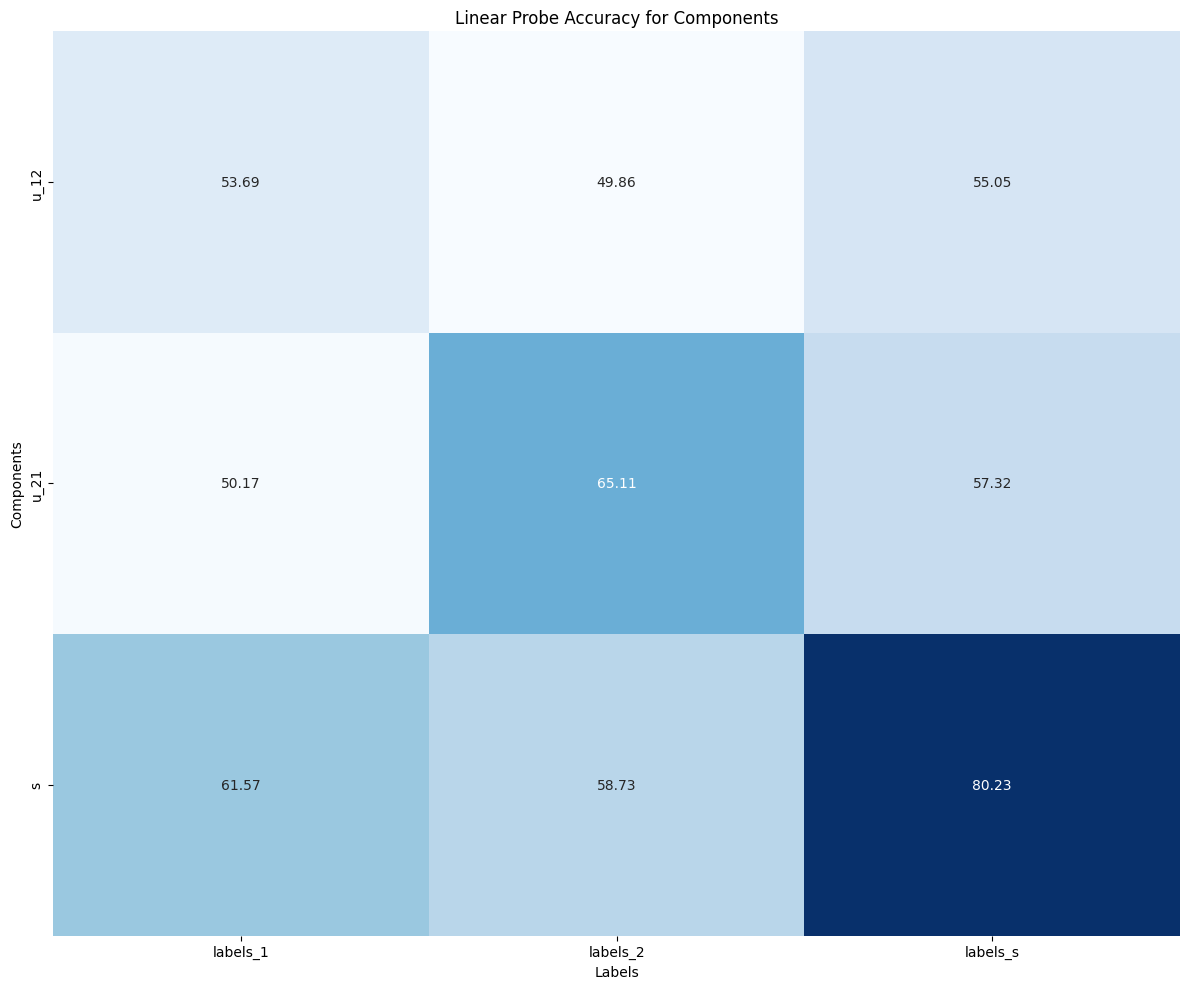

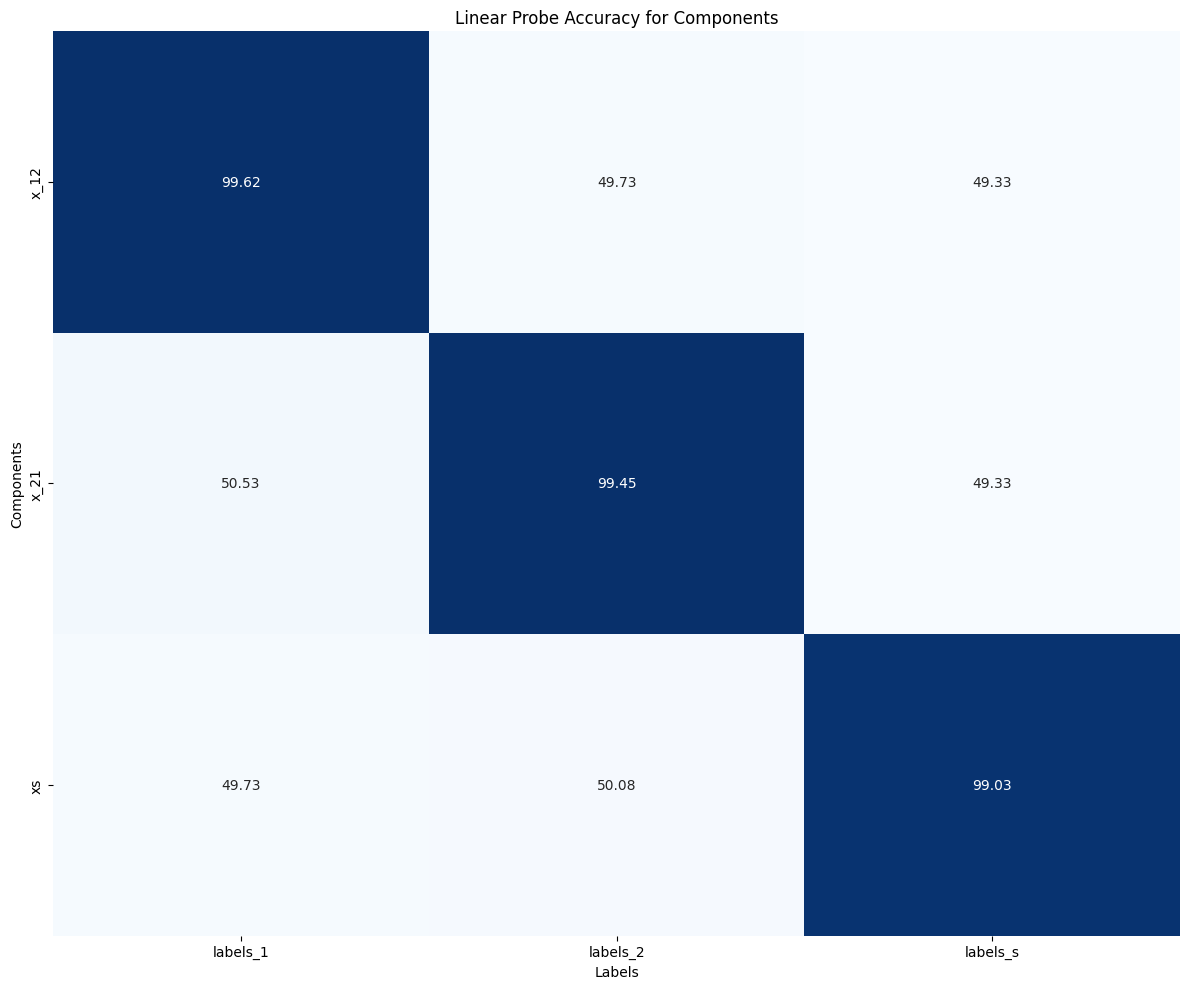

In [90]:
plot_confusion_matrix(linear_probe_acc)
plot_confusion_matrix(input_linear_probe_acc, components= ['x_12', 'x_21', 'xs'])

### Same but non-linear probing

In [91]:
non_linear_probe_acc = {"u_12": np.zeros(3), "u_21": np.zeros(3), "s": np.zeros(3)}
for i, label in enumerate(['labels_1', 'labels_2', 'labels_s']):
    print(f"\nEvaluating disentanglement for {label}...")
    
    # Unique component of modality 1
    non_linear_probe_acc["u_12"][i] = non_linear_probe(
        train_data_dict['u_12'], train_data_dict[label],
        test_data_dict['u_12'], test_data_dict[label]
    )
    print(f"  Unique component of modality 1 accuracy: {non_linear_probe_acc['u_12'][i]:.2f}%")
    # Unique component of modality 2
    non_linear_probe_acc["u_21"][i] = non_linear_probe(
        train_data_dict['u_21'], train_data_dict[label],
        test_data_dict['u_21'], test_data_dict[label]
    )
    print(f"  Unique component of modality 2 accuracy: {non_linear_probe_acc['u_21'][i]:.2f}%")
    # Shared component from modality 2
    non_linear_probe_acc["s"][i] = non_linear_probe(
        np.concatenate((train_data_dict['s_21'], train_data_dict['s_12']), axis= -1), train_data_dict[label],
        np.concatenate((test_data_dict['s_21'], test_data_dict['s_12']), axis= -1), test_data_dict[label]
    )
    print(f"  Shared component accuracy: {non_linear_probe_acc['s'][i]:.2f}%")

input_non_linear_probe_acc = {"x_12": np.zeros(3), "x_21": np.zeros(3), "xs": np.zeros(3)}
for i, label in enumerate(['labels_1', 'labels_2', 'labels_s']):
    print(f"\nEvaluating input data for {label}...")
    
    # Input data from modality 1
    input_non_linear_probe_acc["x_12"][i] = non_linear_probe(
        train_data_dict['x_12'], train_data_dict[label],
        test_data_dict['x_12'], test_data_dict[label]
    )
    print(f"  Input data from modality 1 accuracy: {input_non_linear_probe_acc['x_12'][i]:.2f}%")
    # Input data from modality 2
    input_non_linear_probe_acc["x_21"][i] = non_linear_probe(
        train_data_dict['x_21'], train_data_dict[label],
        test_data_dict['x_21'], test_data_dict[label]
    )
    print(f"  Input data from modality 2 accuracy: {input_non_linear_probe_acc['x_21'][i]:.2f}%")
    # Shared input data
    input_non_linear_probe_acc["xs"][i] = non_linear_probe(
        np.concatenate((train_data_dict['xs_21'], train_data_dict['xs_12']), axis= -1), train_data_dict[label],
        np.concatenate((test_data_dict['xs_21'], test_data_dict['xs_12']), axis= -1), test_data_dict[label]
    )
    print(f"  Shared input data accuracy: {input_non_linear_probe_acc['xs'][i]:.2f}%")
    


Evaluating disentanglement for labels_1...
  Unique component of modality 1 accuracy: 51.18%
  Unique component of modality 2 accuracy: 50.07%
  Shared component accuracy: 61.67%

Evaluating disentanglement for labels_2...
  Unique component of modality 1 accuracy: 50.22%
  Unique component of modality 2 accuracy: 64.74%
  Shared component accuracy: 55.22%

Evaluating disentanglement for labels_s...
  Unique component of modality 1 accuracy: 53.71%
  Unique component of modality 2 accuracy: 55.94%
  Shared component accuracy: 80.08%

Evaluating input data for labels_1...
  Input data from modality 1 accuracy: 99.30%
  Input data from modality 2 accuracy: 50.17%
  Shared input data accuracy: 50.06%

Evaluating input data for labels_2...
  Input data from modality 1 accuracy: 50.28%
  Input data from modality 2 accuracy: 98.72%
  Shared input data accuracy: 50.22%

Evaluating input data for labels_s...
  Input data from modality 1 accuracy: 50.21%
  Input data from modality 2 accuracy: 

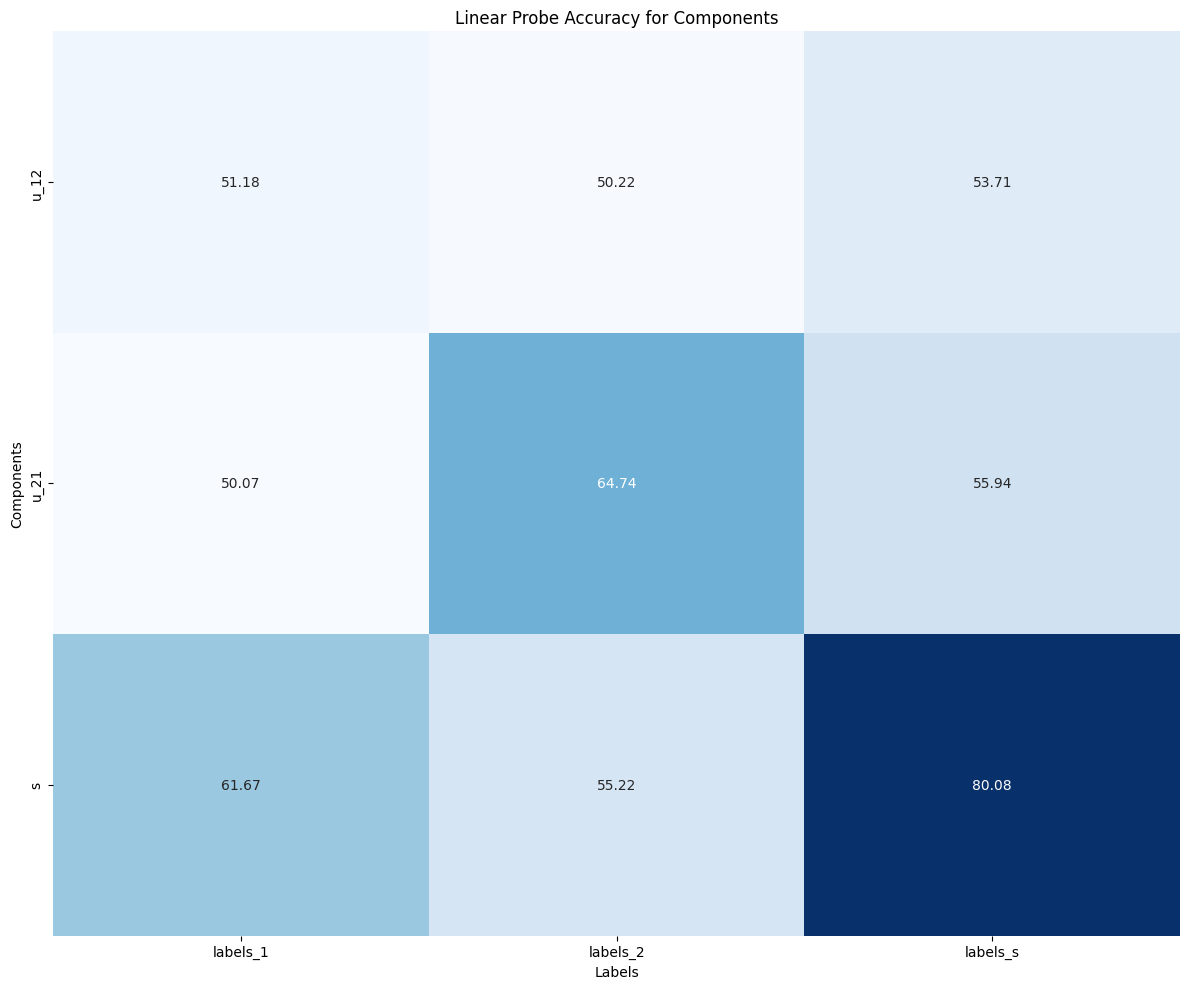

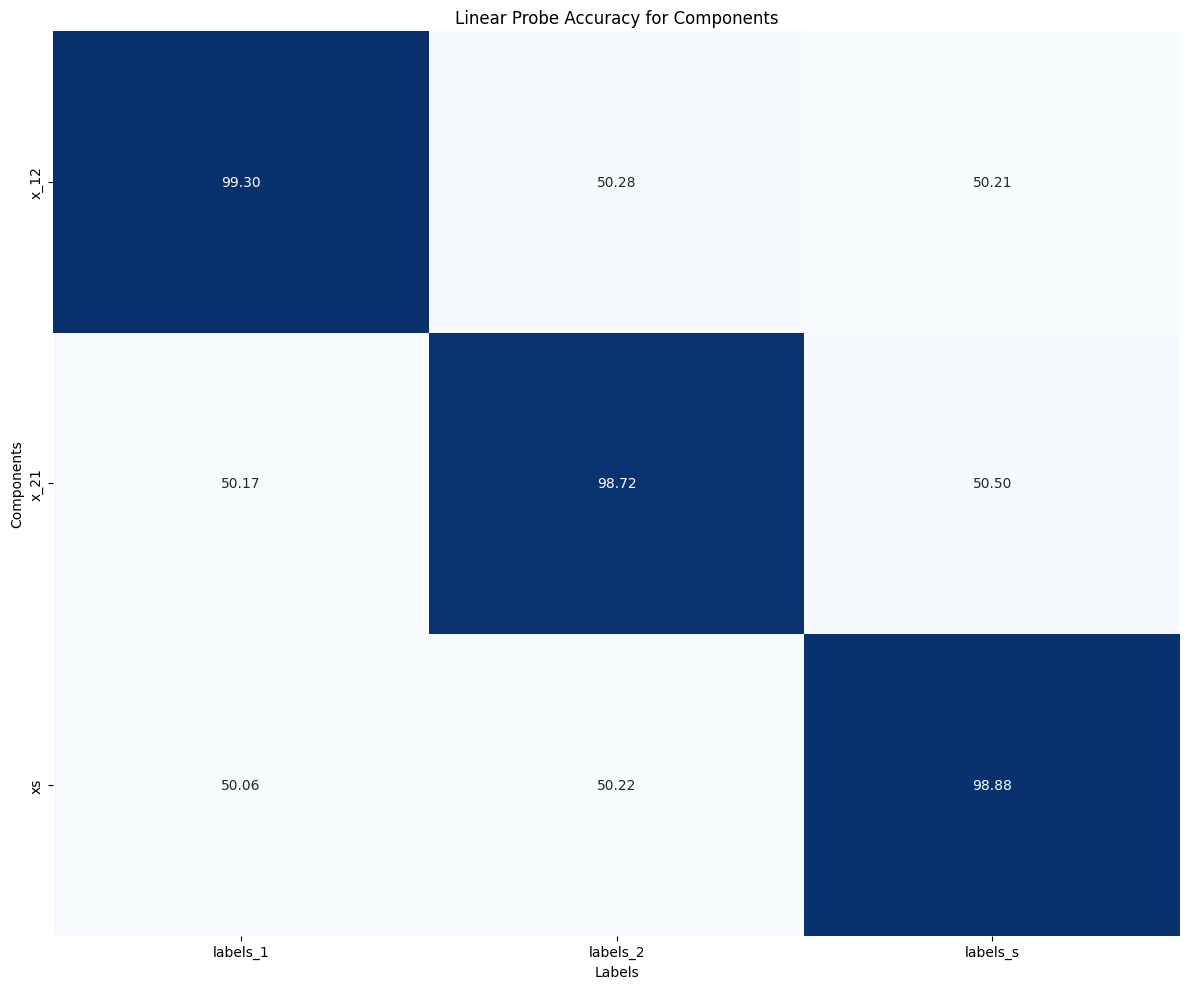

In [92]:
plot_confusion_matrix(non_linear_probe_acc)
plot_confusion_matrix(input_non_linear_probe_acc, components= ['x_12', 'x_21', 'xs'])

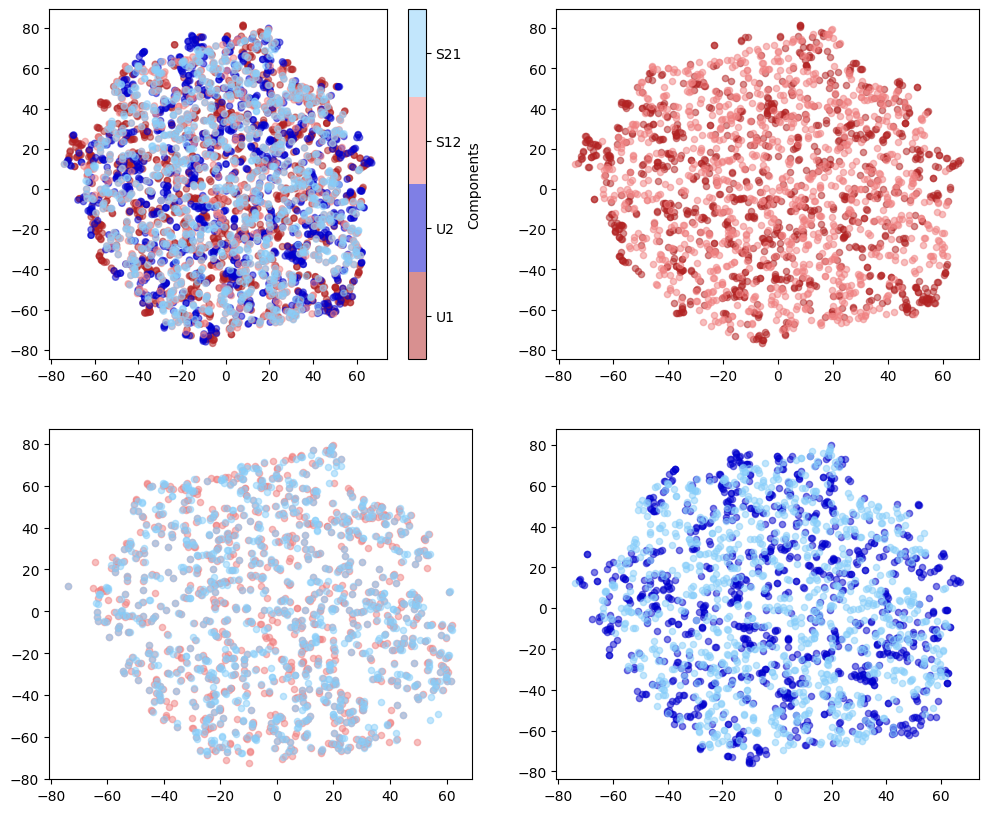

In [93]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import ListedColormap
import pickle as pkl

# Extract the disentangled components from the trained model
model.eval()


# Use a batch from the dataset for visualization
data_m1_viz, data_m2_viz, _, _, _ = next(iter(test_dataloader))

data_m1_viz = data_m1_viz.to(device)
data_m2_viz = data_m2_viz.to(device)

# Forward pass to extract disentangled components
with torch.no_grad():
    outputs_viz = model(data_m1_viz, data_m2_viz)
    
    # Extract components
    z_1 = outputs_viz['Z1'][0].cpu().numpy()  # Unique component from modality 1
    z_2 = outputs_viz['Z2'][0].cpu().numpy()  # Unique component from modality 2
    s_12 = outputs_viz['Z1'][1].cpu().numpy() # shared component from modality 1
    s_21 = outputs_viz['Z2'][1].cpu().numpy() # shared component from modality 2
    
    size = z_1.shape[0]

    labels = [0] * size + [1] * size + size * [2] + size * [3]
    
    # t-SNE 2D visualization
    # Concatenate all components for t-SNE
    concat = np.concatenate([z_1, z_2, s_12, s_21], axis=0)

    # t-SNE 2D visualization
    best_kl = float('inf')
    
    best_tsne = None
    for i in range(1):
        tsne = TSNE(n_components=2, random_state= i, perplexity=20)
        tsne.fit(concat)
        temp_kl = tsne.kl_divergence_
        if temp_kl < best_kl:
            best_kl = temp_kl
            best_tsne = tsne
    tsne_result = best_tsne.fit_transform(concat)



    fig, ax = plt.subplots(2, 2, figsize=(12, 10))
    colors = ['#b22222', '#0000cd', '#f08080', '#87cefa']  # dark red, light red, dark blue, light blue

    # Create colormap
    cmap = ListedColormap(colors)
    scatter3 = ax[0, 0].scatter(tsne_result[:, 0], tsne_result[:, 1], c=labels, cmap= cmap, alpha=0.5, s= 20)

    # Discrete colorbar for four labels
    cbar = fig.colorbar(scatter3, ax=ax[0, 0], ticks=[0, 1, 2, 3], boundaries=[-0.5, 0.5, 1.5, 2.5, 3.5])
    cbar.set_label('Components')
    cbar.set_ticklabels(['U1', 'U2', 'S12', 'S21'])

    ax[0, 1].scatter(tsne_result[:size, 0], tsne_result[:size, 1], c= colors[0], label='U1', alpha=0.5, s=20)
    ax[0, 1].scatter(tsne_result[2*size:3*size, 0], tsne_result[2*size:3*size, 1], c=colors[2], label='S12', alpha=0.5, s=20)

    ax[1, 1].scatter(tsne_result[size:2*size, 0], tsne_result[size:2*size, 1], c= colors[1], label='U2', alpha=0.5, s=20)
    ax[1, 1].scatter(tsne_result[3*size:, 0], tsne_result[3*size:, 1], c=colors[3], label='S21', alpha=0.5, s=20)
    
    ax[1, 0].scatter(tsne_result[2*size:3*size, 0], tsne_result[2*size:3*size, 1], c=colors[2], label='S12', alpha=0.5, s=20)
    ax[1, 0].scatter(tsne_result[3*size:, 0], tsne_result[3*size:, 1], c=colors[3], label='S21', alpha=0.5, s=20)
    plt.show()